## Lesson 2: Python Libraries for Data Science

- **NumPy** — numerical arrays and vectorised computation
- **pandas** — Series and DataFrames for tabular data
- **SciPy** — scientific computing, sparse data, optimisation and statistics
- **SymPy** — symbolic mathematics
- **scikit-learn** — introductory machine learning
- **Matplotlib** — core plotting
- **Seaborn** — statistical visualisation



## Learning outcomes

By the end of the session, You should be able to:

1. Explain what a **Python library** is and why libraries are useful.
2. Identify the main purpose of **NumPy, pandas, SciPy, SymPy, scikit-learn, Matplotlib and Seaborn**.
3. Create and inspect NumPy arrays, including their **dimensions** and **shape**.
4. Create pandas **Series** and **DataFrames**, and perform basic inspection, selection and filtering.
5. Use selected SciPy tools for scientific/statistical tasks.
6. Represent and manipulate a symbolic mathematical expression with SymPy.
7. Explain the basic ideas of **features**, **targets**, **supervised learning** and **unsupervised learning**.
8. Use Matplotlib and Seaborn to create simple visualisations.
9. Select an appropriate Python library for a given data-analytics task.

# 1. Setup

We import the libraries used during the lesson.

### Why aliases?
Python programmers commonly use short aliases:

- `np` → NumPy
- `pd` → pandas
- `plt` → `matplotlib.pyplot`
- `sns` → Seaborn
- `sp` → SymPy

These aliases are conventions, not requirements, but following conventions makes code easier for others to read.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sp

from scipy import constants, stats, optimize
from scipy.sparse import csr_matrix

# Reproducibility: use a fixed random seed whenever randomness is used.
np.random.seed(42)

print("Libraries imported successfully.")

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

Libraries imported successfully.


In [ ]:
df = pd.read_csv("../data/Manchester_house_Dataset[3678].csv", index_col=0)
df.head()

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

In [ ]:
df.dtypes

In [ ]:
df.info()

In [ ]:
sum = df.describe().T
sum[["mean", "std", "min", "25%", "50%", "75%", "max"]]

In [ ]:
print("Missing values in each column:\n", df.isnull().sum())
print("\nTotl Missing values: ", df.isnull().sum().sum())

## A quick map of the ecosystem

| Library | Best thought of as... | Typical use |
|---|---|---|
| **NumPy** | Fast numerical array engine | arrays, matrix-like operations, numerical calculations |
| **pandas** | Table/data manipulation toolkit | CSV/Excel-style data, cleaning, filtering, summaries |
| **SciPy** | Scientific-computing toolbox | optimisation, statistics, sparse data, scientific functions |
| **SymPy** | Symbolic mathematics system | algebra, equations, calculus with symbols |
| **scikit-learn** | Machine-learning toolkit | classification, regression, clustering, preprocessing |
| **Matplotlib** | Core plotting library | line, bar, scatter, histogram and custom plots |
| **Seaborn** | Statistical plotting layer | attractive, concise plots built around DataFrames |

### Key idea
These libraries are not isolated. They are often used **together** in one workflow.

## What is a programming library?

A programming library is a collection of reusable code written to solve common problems.

Instead of writing everything from scratch, we can call tested functions and classes created by other developers.

### Why libraries matter

- **Efficiency** — less code to write
- **Consistency** — common conventions and data structures
- **Reliability** — mature libraries are widely tested
- **Specialisation** — access to advanced algorithms without reimplementing them
- **Collaboration** — other programmers recognise standard APIs

### Analogy
A physical library gives us access to knowledge already written by others.  
A programming library gives us access to **code already written by others**.

### Think–pair–share

For each task, suggest the most suitable library:

1. Store 5 million numerical measurements efficiently.
2. Clean a table of customer records.
3. Run a statistical significance test.
4. Solve an algebraic expression symbolically.
5. Train a classifier.
6. Create a histogram.

Keep your answers — we will check them at the end.

# 2. NumPy

**NumPy** stands for **Numerical Python**.

Its central object is the **`ndarray`**: an n-dimensional array.

NumPy is important because arrays support fast, compact numerical computation and provide the foundation for many other data-science libraries.

### Vocabulary

- **dimension (`ndim`)** — how many axes the array has
- **shape (`shape`)** — the size along each axis
- **size (`size`)** — total number of elements
- **dtype (`dtype`)** — data type stored in the array

## 2.1 One-dimensional array

A 1D array is similar to a list of values.

Before running the next cell, predict:

- `ndim`
- `shape`
- `size`
- `dtype`

In [5]:
arr1 = np.array([0, 1, 2, 3, 4])

print("Array:", arr1)
print("Dimensions:", arr1.ndim)
print("Shape:", arr1.shape)
print("Size:", arr1.size)
print("Data type:", arr1.dtype)

Array: [0 1 2 3 4]
Dimensions: 1
Shape: (5,)
Size: 5
Data type: int64


### Interpreting `(5,)`

The shape `(5,)` means:

- there is **one axis**
- that axis contains **5 elements**

The comma is Python's notation for a one-item tuple.

## 2.2 Two-dimensional array

A 2D array can be visualised as rows and columns.

Predict the shape before running the cell.

In [6]:
arr2 = np.array([
    [0, 1, 2],
    [3, 4, 5]
])

print(arr2)
print("Dimensions:", arr2.ndim)
print("Shape:", arr2.shape)
print("Rows:", arr2.shape[0])
print("Columns:", arr2.shape[1])

[[0 1 2]
 [3 4 5]]
Dimensions: 2
Shape: (2, 3)
Rows: 2
Columns: 3


The shape is `(2, 3)`:

- **2 rows**
- **3 columns**

A useful way to read shapes is from the outside inward.

## 2.3 Three-dimensional array

A 3D array can be thought of as a collection of 2D arrays.

In the following example, predict the shape before running the code.

In [7]:
arr3 = np.array([
    [
        [1, 2, 3],
        [4, 5, 6],
        [7, 8, 9],
        [10, 11, 12]
    ],
    [
        [13, 14, 15],
        [16, 17, 18],
        [19, 20, 21],
        [22, 23, 24]
    ]
])

print("Dimensions:", arr3.ndim)
print("Shape:", arr3.shape)
print("Total elements:", arr3.size)

Dimensions: 3
Shape: (2, 4, 3)
Total elements: 24


### Reading the shape `(2, 4, 3)`

This means:

- 2 blocks
- each block has 4 rows
- each row has 3 values

So the total number of values is:

`2 × 4 × 3 = 24`

## 2.4 Indexing and slicing

Indexing lets us retrieve specific elements.

Remember: Python indexing starts at **0**.

In [8]:
values = np.array([10, 20, 30, 40, 50])

print("First element:", values[0])
print("Third element:", values[2])
print("Last element:", values[-1])
print("Elements from index 1 to 3:", values[1:4])

First element: 10
Third element: 30
Last element: 50
Elements from index 1 to 3: [20 30 40]


In [9]:
matrix = np.array([
    [10, 20, 30],
    [40, 50, 60]
])

print("Element at row 0, column 1:", matrix[0, 1])
print("First row:", matrix[0, :])
print("Second column:", matrix[:, 1])

Element at row 0, column 1: 20
First row: [10 20 30]
Second column: [20 50]


## 2.5 Vectorised operations

One major benefit of NumPy is that we can apply an operation to a whole array at once.

In [10]:
scores = np.array([55, 61, 72, 68, 90])

print("Original scores:", scores)
print("Add 5 to every score:", scores + 5)
print("Double every score:", scores * 2)
print("Mean:", scores.mean())
print("Minimum:", scores.min())
print("Maximum:", scores.max())

Original scores: [55 61 72 68 90]
Add 5 to every score: [60 66 77 73 95]
Double every score: [110 122 144 136 180]
Mean: 69.2
Minimum: 55
Maximum: 90


### Why is vectorisation useful?

Compare these two ideas:

```python
# Loop approach
for each value:
    calculate something

# NumPy approach
result = array * 2
```

The NumPy version is usually:

- shorter
- easier to read
- faster for large numerical datasets

## NumPy activity

Without running code first, predict the result:

```python
x = np.array([[2, 4, 6],
              [8, 10, 12]])

x.ndim
x.shape
x[1, 2]
x[:, 0]
x.mean()
```

Then run the cell below and compare.

In [11]:
x = np.array([
    [2, 4, 6],
    [8, 10, 12]
])

print("ndim:", x.ndim)
print("shape:", x.shape)
print("x[1, 2]:", x[1, 2])
print("first column:", x[:, 0])
print("mean:", x.mean())

ndim: 2
shape: (2, 3)
x[1, 2]: 12
first column: [2 8]
mean: 7.0


# 3. pandas

pandas is designed for working with labelled, tabular data.

Two important pandas data structures are:

1. **Series** — one-dimensional labelled data
2. **DataFrame** — two-dimensional tabular data

### Connection to NumPy
pandas is built on top of NumPy concepts, but adds labels, column names, richer data types and high-level data-manipulation tools.

## 3.1 Series with the default index

In [12]:
a = [1, 3, 5, 7]

my_series = pd.Series(a)

print(my_series)

0    1
1    3
2    5
3    7
dtype: int64


If we do not provide labels, pandas creates an index automatically:

- first element → index `0`
- second element → index `1`
- and so on

The index is not the data itself; it is the **label used to locate the data**.

## 3.2 Series with custom labels

In [13]:
attendance = pd.Series(
    [35, 30, 31, 28, 29],
    index=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
)

print(attendance)

Monday       35
Tuesday      30
Wednesday    31
Thursday     28
Friday       29
dtype: int64


In [14]:
print("Monday attendance:", attendance["Monday"])
print("Mean attendance:", attendance.mean())
print("Days with attendance >= 30:")
print(attendance[attendance >= 30])

Monday attendance: 35
Mean attendance: 30.6
Days with attendance >= 30:
Monday       35
Tuesday      30
Wednesday    31
dtype: int64


### Teaching question
Which is easier to understand?

```python
attendance[0]
```

or

```python
attendance["Monday"]
```

Both can be useful, but meaningful labels make analysis easier to interpret.

## 3.3 DataFrames

A DataFrame has:

- rows
- columns
- a row index
- column labels
- potentially different data types in different columns

It is similar to a spreadsheet or SQL table.

In [15]:
data = {
    "Name": ["John", "Ashraf", "Sarah"],
    "Age": [35, 40, 32]
}

df = pd.DataFrame(data)

df

,Name,Age
0,John,35
1,Ashraf,40
2,Sarah,32


### Read the DataFrame carefully

- `0, 1, 2` are row-index labels
- `Name` and `Age` are column labels
- the remaining entries are the data

## 3.4 Inspecting a DataFrame

These commands are extremely common in real analysis.

In [16]:
students = pd.DataFrame({
    "Name": ["Aisha", "Ben", "Carlos", "Dina", "Ethan", "Farah"],
    "Score": [78, 62, 91, 55, 84, 73],
    "Attendance": [92, 75, 98, 66, 88, 81],
    "Programme": ["DS", "CS", "DS", "CS", "DS", "CS"]
})

students

,Name,Score,Attendance,Programme
0,Aisha,78,92,DS
1,Ben,62,75,CS
2,Carlos,91,98,DS
3,Dina,55,66,CS
4,Ethan,84,88,DS
5,Farah,73,81,CS


In [17]:
print("Shape:", students.shape)
print("\nColumn names:", list(students.columns))
print("\nData types:")
print(students.dtypes)

Shape: (6, 4)

Column names: ['Name', 'Score', 'Attendance', 'Programme']

Data types:
Name            str
Score         int64
Attendance    int64
Programme       str
dtype: object


In [18]:
students.head(3)

,Name,Score,Attendance,Programme
0,Aisha,78,92,DS
1,Ben,62,75,CS
2,Carlos,91,98,DS


In [19]:
students[["Score", "Attendance"]].describe()

,Score,Attendance
count,6.000000,6.000000
mean,73.833333,83.333333
std,13.496913,11.724618
min,55.000000,66.000000
25%,64.750000,76.500000
50%,75.500000,84.500000
75%,82.500000,91.000000
max,91.000000,98.000000


### Important inspection methods

| Method / property | Purpose |
|---|---|
| `df.head()` | preview first rows |
| `df.tail()` | preview last rows |
| `df.shape` | rows × columns |
| `df.columns` | column labels |
| `df.dtypes` | data types |
| `df.info()` | structural overview |
| `df.describe()` | descriptive statistics |

## 3.5 Selecting and filtering data

In [20]:
# Select one column
students["Score"]

0    78
1    62
2    91
3    55
4    84
5    73
Name: Score, dtype: int64

In [21]:
# Select more than one column
students[["Name", "Score"]]

,Name,Score
0,Aisha,78
1,Ben,62
2,Carlos,91
3,Dina,55
4,Ethan,84
5,Farah,73


In [22]:
# Filter rows using a Boolean condition
high_scores = students[students["Score"] >= 75]
high_scores

,Name,Score,Attendance,Programme
0,Aisha,78,92,DS
2,Carlos,91,98,DS
4,Ethan,84,88,DS


In [23]:
# Combine conditions with &
strong_engagement = students[
    (students["Score"] >= 70) &
    (students["Attendance"] >= 80)
]

strong_engagement

,Name,Score,Attendance,Programme
0,Aisha,78,92,DS
2,Carlos,91,98,DS
4,Ethan,84,88,DS
5,Farah,73,81,CS


## 3.6 Creating a new column

In [24]:
students["Passed"] = students["Score"] >= 60
students

,Name,Score,Attendance,Programme,Passed
0,Aisha,78,92,DS,True
1,Ben,62,75,CS,True
2,Carlos,91,98,DS,True
3,Dina,55,66,CS,False
4,Ethan,84,88,DS,True
5,Farah,73,81,CS,True


## pandas activity — class attendance

Create a DataFrame containing:

- Day: Monday to Friday
- Attendance: 35, 30, 31, 28, 29

Then:

1. display the DataFrame
2. calculate mean attendance
3. find the day with the highest attendance
4. filter days where attendance is at least 30

In [25]:
attendance_df = pd.DataFrame({
    "Day": ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"],
    "Attendance": [35, 30, 31, 28, 29]
})

display(attendance_df)

print("Mean attendance:", attendance_df["Attendance"].mean())

highest_row = attendance_df.loc[attendance_df["Attendance"].idxmax()]
print("Highest attendance:", highest_row["Day"], "-", highest_row["Attendance"])

display(attendance_df[attendance_df["Attendance"] >= 30])

,Day,Attendance
0,Monday,35
1,Tuesday,30
2,Wednesday,31
3,Thursday,28
4,Friday,29


Mean attendance: 30.6
Highest attendance: Monday - 35


,Day,Attendance
0,Monday,35
1,Tuesday,30
2,Wednesday,31


# 4. SciPy

**SciPy** extends NumPy with tools for scientific and technical computing.

Examples include:

- scientific constants
- optimisation
- sparse data
- statistical tests
- interpolation
- integration
- signal processing

Think of NumPy as the numerical foundation and SciPy as a collection of specialised scientific tools built around it.

## 4.1 Scientific constants

In [26]:
print("Pi:", constants.pi)
print("1 litre in cubic metres:", constants.liter)
print("1 minute in seconds:", constants.minute)

Pi: 3.141592653589793
1 litre in cubic metres: 0.001
1 minute in seconds: 60.0


## 4.2 Sparse data

A sparse dataset contains many zero or empty values.

For very large matrices, storing every zero explicitly can waste memory.

SciPy provides sparse matrix formats such as:

- **CSR** — Compressed Sparse Row
- **CSC** — Compressed Sparse Column

In [27]:
arr = np.array([0, 0, 0, 0, 0, 0, 1, 1, 0, 2, 0, 1, 2])

sparse_arr = csr_matrix(arr)

print(sparse_arr)

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 5 stored elements and shape (1, 13)>
  Coords	Values
  (0, 6)	1
  (0, 7)	1
  (0, 9)	2
  (0, 11)	1
  (0, 12)	2


In [28]:
print("Stored non-zero values:", sparse_arr.data)
print("Number of non-zero values:", sparse_arr.count_nonzero())

Stored non-zero values: [1 1 2 1 2]
Number of non-zero values: 5


### Why sparse structures matter

Examples of naturally sparse data:

- user–product recommendation matrices
- word/document matrices in natural-language processing
- network adjacency matrices
- high-dimensional scientific measurements

The goal is not to "remove zeros" conceptually; it is to **store and process the same information more efficiently**.

## 4.3 Optimisation

Optimisation asks:

> Which input gives the minimum or maximum value of a function?

For example:

- minimum cost
- maximum profit
- lowest error
- shortest distance

Below we minimise the function:

\[
f(x) = (x - 3)^2 + 2
\]

Its minimum should occur close to `x = 3`.

In [29]:
def objective(x):
    return (x - 3)**2 + 2

result = optimize.minimize_scalar(objective)

print("Estimated x at minimum:", result.x)
print("Minimum function value:", result.fun)

Estimated x at minimum: 3.0
Minimum function value: 2.0


## 4.4 Significance testing

A statistical significance test helps us assess whether an observed result is consistent with a null hypothesis.

### Core terms

- **Null hypothesis (H₀)** — default claim, often "no difference" or "no effect"
- **Alternative hypothesis (H₁)** — competing claim
- **p-value** — how surprising the observed data would be if H₀ were true

A common classroom convention is:

- `p < 0.05` → evidence against H₀
- `p >= 0.05` → insufficient evidence to reject H₀

> This does **not** mean that a p-value gives the probability that H₀ is true.

In [30]:
sample_scores = np.array([72, 68, 75, 71, 74, 69, 77, 73, 70, 76])

# Example question:
# Is the sample mean different from a reference value of 70?
t_stat, p_value = stats.ttest_1samp(sample_scores, popmean=70)

print("Sample mean:", sample_scores.mean())
print("t statistic:", t_stat)
print("p value:", p_value)

Sample mean: 72.5
t statistic: 2.6111648393354674
p value: 0.028216803759726603


### Discussion
At a 5% significance level:

- What is H₀?
- What is H₁?
- Is the p-value below 0.05?
- What conclusion would you report?

Focus on careful wording: **"reject"** or **"fail to reject"** the null hypothesis.

# 5. SymPy

SymPy is a **computer algebra system (CAS)**.

The key distinction is:

- NumPy works mainly with **numerical values**
- SymPy can work with **symbols and exact mathematical expressions**

This is useful when the value of a variable is unknown.

## 5.1 Creating a symbolic expression

We want to represent:

\[
3x^2 + 5
\]

In [31]:
x = sp.symbols("x")
expr = 3*(x**2) + 5

expr

3*x**2 + 5

In Python:

- `*` means multiplication
- `**` means exponentiation ("to the power of")

So:

```python
3*(x**2)
```

means:

\[
3x^2
\]

## 5.2 Manipulating expressions

In [32]:
expr_plus_10 = expr + 10

print("Original expression:", expr)
print("After adding 10:", expr_plus_10)

Original expression: 3*x**2 + 5
After adding 10: 3*x**2 + 15


In [33]:
expanded = sp.expand((x + 2) * (x + 3))
factored = sp.factor(x**2 + 5*x + 6)

print("Expanded:", expanded)
print("Factored:", factored)

Expanded: x**2 + 5*x + 6
Factored: (x + 2)*(x + 3)


## 5.3 Solving an equation

In [34]:
solution = sp.solve(sp.Eq(x**2 - 9, 0), x)
print("Solutions to x² - 9 = 0:", solution)

Solutions to x² - 9 = 0: [-3, 3]


## 5.4 Symbolic differentiation

This is extension material if students are comfortable with calculus.

In [35]:
f = 3*x**2 + 5*x - 2
derivative = sp.diff(f, x)

print("f(x) =", f)
print("f'(x) =", derivative)

f(x) = 3*x**2 + 5*x - 2
f'(x) = 6*x + 5


### SymPy activity

Create the expression:

\[
4x^3 - 2x + 9
\]

Then:

1. print it
2. calculate its derivative
3. substitute `x = 2`

In [36]:
expr2 = 4*x**3 - 2*x + 9

print("Expression:", expr2)
print("Derivative:", sp.diff(expr2, x))
print("Value when x = 2:", expr2.subs(x, 2))

Expression: 4*x**3 - 2*x + 9
Derivative: 12*x**2 - 2
Value when x = 2: 37


# 6. scikit-learn

scikit-learn is one of the main Python libraries for **machine learning**.

### Basic terminology

- **Feature (`X`)** — information used to make a prediction
- **Target (`y`)** — value or category we want to predict
- **Model** — learned relationship between features and target

### Two broad learning types

**Supervised learning**
- target is known during training
- examples: regression and classification

**Unsupervised learning**
- no target labels are provided
- algorithm looks for structure or patterns
- example: clustering

## 6.1 Typical machine-learning workflow

1. Collect data
2. Inspect and clean data
3. Select features and target
4. Split data into training and test sets
5. Choose a model
6. Train (`fit`) the model
7. Make predictions
8. Evaluate performance
9. Refine and eventually deploy

We will run a small classification example using a built-in dataset so that no external file is required.

In [38]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [39]:
iris = load_iris(as_frame=True)

iris_df = iris.frame
iris_df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


The Iris dataset contains measurements of flowers.

The feature columns describe flower measurements.  
The target indicates the species category.

In [40]:
print("Dataset shape:", iris_df.shape)
print("Feature names:", iris.feature_names)
print("Target names:", iris.target_names)
print("\nTarget counts:")
print(iris_df["target"].value_counts().sort_index())

Dataset shape: (150, 5)
Feature names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target names: ['setosa' 'versicolor' 'virginica']

Target counts:
target
0    50
1    50
2    50
Name: count, dtype: int64


In [41]:
X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Test rows:", X_test.shape[0])

Training rows: 112
Test rows: 38


In [42]:
model = LogisticRegression(max_iter=300)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)
print("Accuracy:", accuracy)

Accuracy: 0.9473684210526315


In [43]:
cm = confusion_matrix(y_test, predictions)
cm

array([[12,  0,  0],
       [ 0, 12,  1],
       [ 0,  1, 12]])

### Interpreting accuracy

Accuracy is:

\[
\frac{\text{correct predictions}}{\text{all predictions}}
\]

A high accuracy on this small demonstration is useful for learning the workflow, but in real projects we would also consider:

- class balance
- precision
- recall
- F1-score
- cross-validation
- data leakage
- fairness and context

### Teaching question

Which of the following is a **feature** and which is a **target**?

> Predict whether a student will pass a module using:
> attendance, previous grade, study hours, and engagement.

**Discuss before revealing:**

- Features → attendance, previous grade, study hours, engagement
- Target → pass/fail

# 7. Matplotlib

Matplotlib is a general-purpose plotting library.

A common import is:

```python
import matplotlib.pyplot as plt
```

`pyplot` provides high-level plotting functions.

## 7.1 Simple line plot

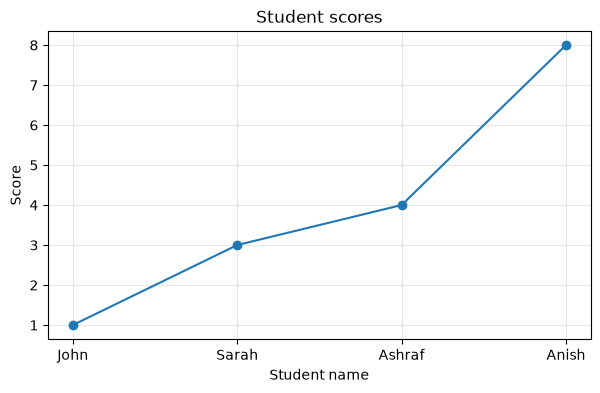

In [44]:
names = np.array(["John", "Sarah", "Ashraf", "Anish"])
scores = np.array([1, 3, 4, 8])

plt.figure(figsize=(7, 4))
plt.plot(names, scores, marker="o")
plt.xlabel("Student name")
plt.ylabel("Score")
plt.title("Student scores")
plt.grid(alpha=0.3)
plt.show()

### Plot-choice discussion

A line plot suggests an ordered sequence or trend.

For independent student categories, a **bar chart** may communicate the comparison more naturally.

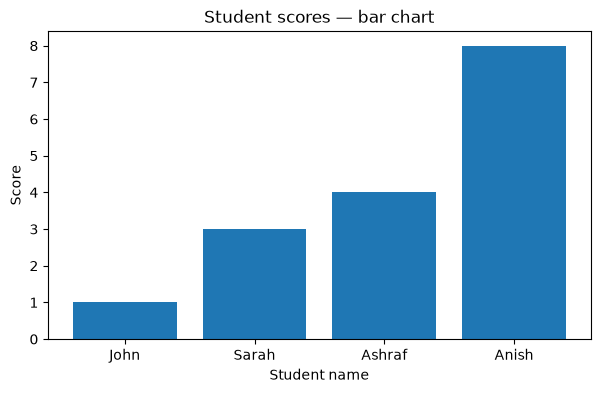

In [45]:
plt.figure(figsize=(7, 4))
plt.bar(names, scores)
plt.xlabel("Student name")
plt.ylabel("Score")
plt.title("Student scores — bar chart")
plt.show()

## 7.2 Scatter plot

Use a scatter plot to investigate the relationship between two numerical variables.

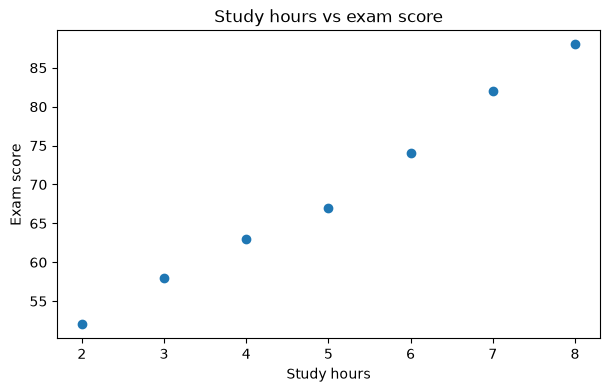

In [46]:
study_hours = np.array([2, 3, 4, 5, 6, 7, 8])
exam_scores = np.array([52, 58, 63, 67, 74, 82, 88])

plt.figure(figsize=(7, 4))
plt.scatter(study_hours, exam_scores)
plt.xlabel("Study hours")
plt.ylabel("Exam score")
plt.title("Study hours vs exam score")
plt.show()

# 8. Seaborn

Seaborn is a statistical visualisation library built on Matplotlib.

It works especially well with pandas DataFrames.

A common import is:

```python
import seaborn as sns
```

### Why use Seaborn?

- concise syntax
- good defaults
- statistical visualisations
- easy grouping using variables such as `hue`
- natural integration with DataFrames

## 8.1 Histogram

A histogram shows the distribution of a numerical variable.

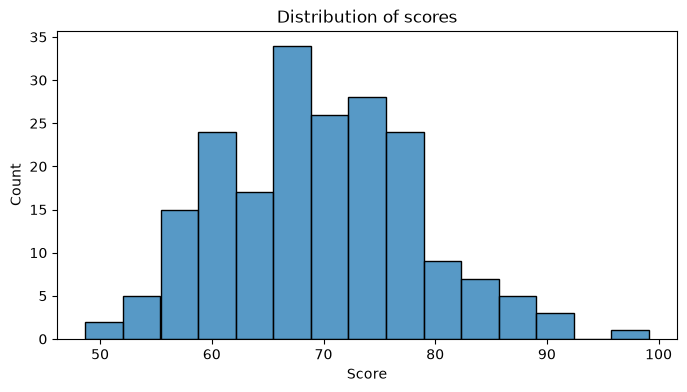

In [47]:
rng = np.random.default_rng(42)

demo_df = pd.DataFrame({
    "Score": rng.normal(70, 10, 200).clip(0, 100),
    "Group": rng.choice(["A", "B"], size=200)
})

plt.figure(figsize=(8, 4))
sns.histplot(data=demo_df, x="Score", bins=15)
plt.title("Distribution of scores")
plt.show()

## 8.2 Histogram with `hue`

`hue` splits the visualisation by a categorical variable.

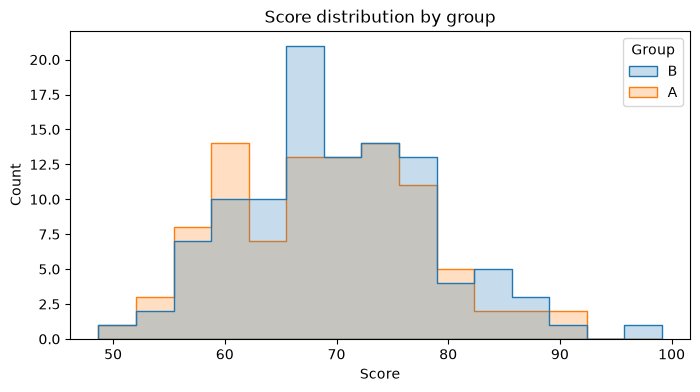

In [48]:
plt.figure(figsize=(8, 4))
sns.histplot(
    data=demo_df,
    x="Score",
    hue="Group",
    bins=15,
    element="step",
    stat="count",
    common_norm=False
)
plt.title("Score distribution by group")
plt.show()

## 8.3 Box plot

A box plot helps compare distributions across categories and can highlight spread and potential outliers.

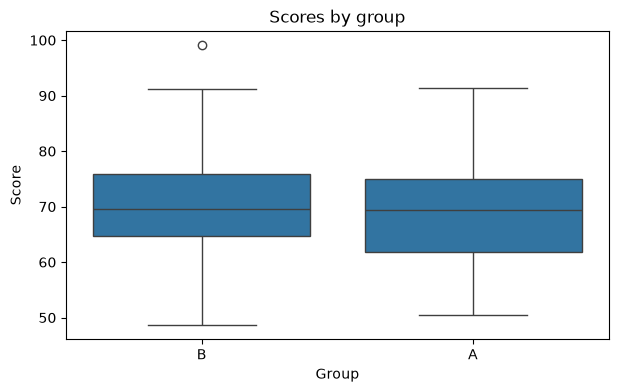

In [49]:
plt.figure(figsize=(7, 4))
sns.boxplot(data=demo_df, x="Group", y="Score")
plt.title("Scores by group")
plt.show()

## Matplotlib vs Seaborn

This is not really an either/or choice.

- Matplotlib provides lower-level control and is the plotting foundation.
- Seaborn provides convenient statistical visualisations and good DataFrame integration.
- Seaborn still uses Matplotlib underneath.

In practice, analysts frequently use both in the same notebook.

# 9. Integrated mini-case

We now combine several libraries in one small workflow.

### Scenario

A lecturer has a small dataset containing:

- student name
- study hours
- attendance percentage
- assessment score

We want to:

1. store the data in pandas
2. inspect and summarise it
3. calculate a NumPy statistic
4. run a SciPy correlation test
5. visualise relationships
6. discuss how scikit-learn could be used later

In [50]:
student_data = pd.DataFrame({
    "Student": ["A", "B", "C", "D", "E", "F", "G", "H", "I", "J"],
    "StudyHours": [3, 5, 2, 7, 6, 4, 8, 5, 9, 3],
    "Attendance": [70, 82, 65, 91, 88, 78, 96, 84, 98, 72],
    "Score": [58, 69, 52, 84, 79, 65, 92, 73, 95, 60]
})

student_data

,Student,StudyHours,Attendance,Score
0,A,3,70,58
1,B,5,82,69
2,C,2,65,52
3,D,7,91,84
4,E,6,88,79
5,F,4,78,65
6,G,8,96,92
7,H,5,84,73
8,I,9,98,95
9,J,3,72,60


In [51]:
student_data[["StudyHours", "Attendance", "Score"]].describe()

,StudyHours,Attendance,Score
count,10.000000,10.000000,10.000000
mean,5.200000,82.400000,72.700000
std,2.299758,11.157459,14.591093
min,2.000000,65.000000,52.000000
25%,3.250000,73.500000,61.250000
50%,5.000000,83.000000,71.000000
75%,6.750000,90.250000,82.750000
max,9.000000,98.000000,95.000000


In [ ]:
scores_np = student_data["Score"].to_numpy()

print("Mean score:", np.mean(scores_np))
print("Median score:", np.median(scores_np))
print("Standard deviation:", np.std(scores_np, ddof=1))

## Correlation

We ask:

> Is there evidence of a linear relationship between study hours and assessment score?

SciPy's Pearson correlation returns:

- correlation coefficient `r`
- p-value

In [52]:
r, p = stats.pearsonr(
    student_data["StudyHours"],
    student_data["Score"]
)

print("Pearson r:", r)
print("p-value:", p)

Pearson r: 0.9953513606090997
p-value: 2.031686843364874e-09


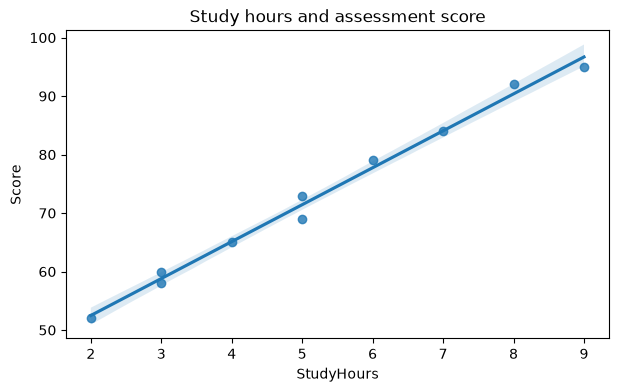

In [53]:
plt.figure(figsize=(7, 4))
sns.regplot(
    data=student_data,
    x="StudyHours",
    y="Score"
)
plt.title("Study hours and assessment score")
plt.show()

### Interpretation prompt


1. Is the relationship positive or negative?
2. Is it weak, moderate or strong?
3. What does the p-value suggest in this small example?
4. Can we say that more study hours **cause** higher scores?

> **Important:** Correlation does not by itself establish causation.

## Simple predictive model

If this were a larger, appropriate dataset, we could use scikit-learn to build a model such as:

- regression → predict a numerical score
- classification → predict pass/fail

Before modelling, we would need to think about data quality, sample size, ethics, fairness, leakage and whether prediction is actually appropriate.

# 10. Common mistakes to discuss

### Import mistakes

Incorrect:
```python
import NumPy as np
```

Correct:
```python
import numpy as np
```

Python package names are case-sensitive in import statements.

---

### Confusing shape with dimension

For an array with shape `(2, 3)`:

- `ndim` is `2`
- shape is `(2, 3)`
- total size is `6`

---

### Confusing pandas index and column data

The index labels identify rows; they are not automatically part of the data columns.

---

### Running notebook cells out of order

A later cell may depend on a variable created earlier.

If `x` has not been defined, this fails:

```python
expr = 3*x**2 + 5
```

---

### Random results changing every run

For teaching, set a random seed when appropriate so that lecturer and students can reproduce the same result.

# 11. Which library should I use?

| Task | Good starting library |
|---|---|
| Numerical arrays | NumPy |
| Vectorised numerical calculation | NumPy |
| Tabular data | pandas |
| CSV / spreadsheet-like analysis | pandas |
| Statistical tests | SciPy |
| Optimisation | SciPy |
| Sparse matrices | SciPy |
| Symbolic algebra | SymPy |
| Classification / regression | scikit-learn |
| Clustering | scikit-learn |
| General plotting | Matplotlib |
| Statistical DataFrame visualisation | Seaborn |

### Remember
Real projects usually involve **multiple libraries**, not one library in isolation.

# 12. Knowledge check

Try to answer without looking back.

1. What is a Python library?
2. What does `ndim` tell us?
3. What does `shape` tell us?
4. What are the two main pandas data structures introduced today?
5. What is sparse data?
6. What is a null hypothesis?
7. What is the difference between NumPy and SymPy?
8. In machine learning, what is a feature?
9. What is a target?
10. What is the difference between supervised and unsupervised learning?
11. Which library would you choose for a histogram?
12. Why might you choose Seaborn when working with a pandas DataFrame?

<details>
<summary><strong>Suggested answers</strong></summary>

1. A collection of reusable code for common tasks.
2. The number of dimensions/axes in an array.
3. The size of the array along each axis.
4. Series and DataFrame.
5. Data where many positions contain zero / no stored value, often represented efficiently with sparse structures.
6. The default statistical hypothesis, commonly representing no effect or no difference.
7. NumPy performs numerical computation; SymPy works with symbolic mathematical expressions.
8. An input variable used by a model.
9. The value/category the model is intended to predict.
10. Supervised learning uses known target labels during training; unsupervised learning looks for patterns without known targets.
11. Matplotlib or Seaborn.
12. Seaborn integrates naturally with DataFrames and provides concise statistical plotting functions.

</details>

# 13. Challenge

Create a small dataset for **8 students** with:

- `Name`
- `StudyHours`
- `Attendance`
- `Score`

Then complete the following:

### Part A — pandas
1. Build a DataFrame.
2. Show the first five rows.
3. Calculate the mean score.
4. Filter students with a score of at least 70.
5. Add a Boolean column called `Passed`.

### Part B — NumPy
6. Convert the `Score` column to a NumPy array.
7. Find the minimum, maximum and standard deviation.

### Part C — Visualisation
8. Create a histogram of scores using Seaborn.
9. Create a scatter plot of study hours vs score.

### Part D — Interpretation
10. Write two sentences describing what you observe.

### Extension
Use SciPy to calculate Pearson correlation between study hours and score.

# 14. Lesson summary

Today we saw that Python's data-science strength comes largely from its ecosystem of libraries.

### Core takeaways

- **NumPy** gives us efficient n-dimensional arrays.
- **pandas** gives us labelled Series and DataFrames.
- **SciPy** extends scientific and statistical computing.
- **SymPy** lets us manipulate symbolic mathematics.
- **scikit-learn** provides a consistent machine-learning toolkit.
- **Matplotlib** provides flexible plotting.
- **Seaborn** makes statistical plotting with DataFrames convenient.

### Final reflection

Return to the diagnostic questions from the beginning.

Can you now explain **which library you would choose, and why**, for a new data-analytics task?

## Wrap-up prompts

Use one or two before finishing:

- Which library felt most intuitive?
- Which concept was least clear?
- What is one example where pandas and NumPy would be used together?
- Why is it useful that scikit-learn uses NumPy/pandas-style data?
- What would you like to practise more before the next lesson?

### Suggested preparation for the next class
Try to practise:
- array indexing
- DataFrame filtering
- interpreting simple visualisations